# Live Voice Denoising Demo 1.0

This notebook is designed for the live presentation demo.

Flow:
1. Record a new 10-second voice sample from the laptop microphone.
2. Add simulated high-frequency hiss noise.
3. Show waveform and play raw/noisy audio.
4. Apply the baseline low-pass filter.
5. Apply the Wiener-style time-frequency mask.
6. Compare waveform, spectrogram, and audio outputs.

Before presenting, run the setup cell once. During presentation, run the following cells step by step.

## Cell 1｜Setup

In [1]:
from __future__ import annotations

from pathlib import Path
from math import gcd
import warnings

import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from scipy import signal
from IPython.display import Audio, display

try:
    import sounddevice as sd
except Exception as exc:
    sd = None
    print("sounddevice is not available. Set USE_MIC = False to use the backup audio.")
    print("Import message:", exc)

# -----------------------------
# Live demo parameters
# -----------------------------
USE_MIC = True                 # If microphone permission fails, set this to False.
RECORD_SECONDS = 10
FS = 16_000
RANDOM_SEED = 402

# The noise level is intentionally obvious for classroom demonstration.
TARGET_SNR_DB = 0.0            # lower value means stronger added hiss
HISS_HIGHPASS_HZ = 3_200

# Baseline low-pass settings.
LOWPASS_CUTOFF_HZ = 3_000
LOWPASS_ORDER = 6

# Wiener-style mask settings.
N_PER_SEG = 1024
NO_OVERLAP = 768
MASK_FLOOR = 0.10
NOISE_OVER_ESTIMATE = 0.45
MASK_SMOOTHING_BINS = 3

# Paths. The notebook may be launched from repo root, demo/code, or another nearby folder.
def find_demo_dir() -> Path:
    start = Path.cwd().resolve()
    candidates = []
    for base in [start, *start.parents]:
        candidates.extend([
            base,
            base / "demo",
            base / "SSP_CP" / "demo",
        ])
    fixed = Path("/Users/xiejz959/Xiejz/College/Signal System & Probability/project/SSP_CP/demo")
    candidates.append(fixed)

    for candidate in candidates:
        if (candidate / "Voices" / "clean_voice_3.1.wav").exists():
            return candidate
    raise FileNotFoundError("Cannot find demo/Voices/clean_voice_3.1.wav. Please open this notebook inside the SSP_CP project.")

DEMO_DIR = find_demo_dir()
OUTPUT_DIR = DEMO_DIR / "live_demo_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BACKUP_AUDIO = DEMO_DIR / "Voices" / "clean_voice_3.1.wav"

RAW_PATH = OUTPUT_DIR / "live_raw.wav"
NOISE_PATH = OUTPUT_DIR / "live_hiss_noise.wav"
NOISY_PATH = OUTPUT_DIR / "live_noisy.wav"
LOWPASS_PATH = OUTPUT_DIR / "live_lowpass.wav"
MASK_PATH = OUTPUT_DIR / "live_mask.wav"

print("Output directory:", OUTPUT_DIR)
print("Backup audio:", BACKUP_AUDIO)

# -----------------------------
# Helper functions
# -----------------------------
def to_mono(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x)
    if x.ndim > 1:
        x = x.mean(axis=1)
    return x.astype(np.float64)


def resample_if_needed(x: np.ndarray, fs_in: int, fs_out: int) -> np.ndarray:
    if fs_in == fs_out:
        return x
    factor = gcd(fs_in, fs_out)
    up = fs_out // factor
    down = fs_in // factor
    return signal.resample_poly(x, up, down)


def normalize_peak(x: np.ndarray, peak: float = 0.92) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    m = np.max(np.abs(x)) if len(x) else 0
    if m < 1e-12:
        return x.copy()
    return x * (peak / m)


def preprocess_audio(x: np.ndarray, fs: int, seconds: float | None = None) -> np.ndarray:
    x = to_mono(x)
    x = x - np.mean(x)
    if seconds is not None:
        target_len = int(seconds * fs)
        if len(x) < target_len:
            x = np.pad(x, (0, target_len - len(x)))
        else:
            x = x[:target_len]
    return normalize_peak(x, 0.88)


def save_wav(path: Path, x: np.ndarray, fs: int = FS) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    sf.write(path, normalize_peak(x, 0.92), fs)
    return path


def read_wav(path: Path) -> tuple[np.ndarray, int]:
    x, fs = sf.read(path)
    return to_mono(x), fs


def rms(x: np.ndarray) -> float:
    return float(np.sqrt(np.mean(np.asarray(x) ** 2) + 1e-12))


def match_length(*signals_: np.ndarray) -> list[np.ndarray]:
    n = min(len(x) for x in signals_)
    return [np.asarray(x)[:n] for x in signals_]


def make_hiss_noise(reference: np.ndarray, fs: int, snr_db: float, seed: int = RANDOM_SEED) -> np.ndarray:
    rng = np.random.default_rng(seed)
    white = rng.standard_normal(len(reference))
    sos = signal.butter(6, HISS_HIGHPASS_HZ, btype="highpass", fs=fs, output="sos")
    hiss = signal.sosfiltfilt(sos, white)
    # Scale noise to a target SNR relative to the live voice.
    target_noise_rms = rms(reference) / (10 ** (snr_db / 20))
    hiss = hiss / (rms(hiss) + 1e-12) * target_noise_rms
    return hiss


def butter_lowpass(x: np.ndarray, fs: int, cutoff_hz: float = LOWPASS_CUTOFF_HZ, order: int = LOWPASS_ORDER) -> np.ndarray:
    sos = signal.butter(order, cutoff_hz, btype="lowpass", fs=fs, output="sos")
    y = signal.sosfiltfilt(sos, x)
    return normalize_peak(y, 0.92)


def smooth_mask_frequency(mask: np.ndarray, bins: int = MASK_SMOOTHING_BINS) -> np.ndarray:
    if bins <= 1:
        return mask
    kernel = np.ones(bins) / bins
    smoothed = np.empty_like(mask)
    for frame in range(mask.shape[1]):
        smoothed[:, frame] = np.convolve(mask[:, frame], kernel, mode="same")
    return smoothed


def wiener_style_mask_filter(noisy: np.ndarray, noise: np.ndarray, fs: int) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    freqs, times, noisy_stft = signal.stft(
        noisy,
        fs=fs,
        window="hann",
        nperseg=N_PER_SEG,
        noverlap=NO_OVERLAP,
        boundary="zeros",
        padded=True,
    )
    _, _, noise_stft = signal.stft(
        noise,
        fs=fs,
        window="hann",
        nperseg=N_PER_SEG,
        noverlap=NO_OVERLAP,
        boundary="zeros",
        padded=True,
    )

    noisy_power = np.abs(noisy_stft) ** 2
    noise_power = np.abs(noise_stft) ** 2
    speech_power_est = np.maximum(noisy_power - NOISE_OVER_ESTIMATE * noise_power, 0.0)

    mask = speech_power_est / (speech_power_est + noise_power + 1e-12)
    mask = smooth_mask_frequency(mask, MASK_SMOOTHING_BINS)
    mask = np.clip(mask, MASK_FLOOR, 1.0)

    enhanced_stft = noisy_stft * mask
    _, enhanced = signal.istft(
        enhanced_stft,
        fs=fs,
        window="hann",
        nperseg=N_PER_SEG,
        noverlap=NO_OVERLAP,
        input_onesided=True,
        boundary=True,
    )
    enhanced = enhanced[: len(noisy)]
    return normalize_peak(enhanced, 0.92), mask, freqs, times


def spectrogram_db(x: np.ndarray, fs: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    freqs, times, spec = signal.spectrogram(
        x,
        fs=fs,
        window="hann",
        nperseg=N_PER_SEG,
        noverlap=NO_OVERLAP,
        scaling="spectrum",
        mode="magnitude",
    )
    return freqs, times, 20 * np.log10(spec + 1e-8)


def plot_waveforms(signals_dict: dict[str, np.ndarray], fs: int, title: str, save_name: str | None = None):
    fig, axes = plt.subplots(len(signals_dict), 1, figsize=(12, 2.25 * len(signals_dict)), sharex=True)
    if len(signals_dict) == 1:
        axes = [axes]
    colors = ["#0A84FF", "#FF453A", "#30D158", "#BF5AF2", "#FFD60A"]
    for ax, (idx, (label, x)) in zip(axes, enumerate(signals_dict.items())):
        t = np.arange(len(x)) / fs
        ax.plot(t, x, linewidth=0.8, color=colors[idx % len(colors)])
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.25)
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(title, fontsize=16, fontweight="bold")
    fig.tight_layout()
    if save_name:
        fig.savefig(OUTPUT_DIR / save_name, dpi=180, bbox_inches="tight")
    plt.show()


def plot_spectrograms(signals_dict: dict[str, np.ndarray], fs: int, title: str, save_name: str | None = None):
    fig, axes = plt.subplots(1, len(signals_dict), figsize=(5.2 * len(signals_dict), 4.2), sharey=True)
    if len(signals_dict) == 1:
        axes = [axes]
    last_img = None
    for ax, (label, x) in zip(axes, signals_dict.items()):
        f, t, spec_db = spectrogram_db(x, fs)
        last_img = ax.pcolormesh(t, f, spec_db, shading="gouraud", cmap="magma")
        ax.set_title(label)
        ax.set_xlabel("Time (s)")
        ax.set_ylim(0, fs / 2)
        ax.grid(False)
    axes[0].set_ylabel("Frequency (Hz)")
    fig.suptitle(title, fontsize=16, fontweight="bold")
    fig.subplots_adjust(right=0.90, wspace=0.18)
    cax = fig.add_axes([0.92, 0.18, 0.015, 0.62])
    fig.colorbar(last_img, cax=cax, label="Magnitude (dB)")
    if save_name:
        fig.savefig(OUTPUT_DIR / save_name, dpi=180, bbox_inches="tight")
    plt.show()


def show_audio(label: str, x: np.ndarray, fs: int = FS):
    print(label)
    display(Audio(normalize_peak(x, 0.92), rate=fs))

Output directory: /Users/xiejz959/Xiejz/College/Signal System & Probability/project/SSP_CP/demo/live_demo_outputs
Backup audio: /Users/xiejz959/Xiejz/College/Signal System & Probability/project/SSP_CP/demo/Voices/clean_voice_3.1.wav


## Cell 2｜Record 10 Seconds of Live Voice

Recording 10 seconds. Please speak after the recording starts...
Saved: /Users/xiejz959/Xiejz/College/Signal System & Probability/project/SSP_CP/demo/live_demo_outputs/live_raw.wav
Raw live voice


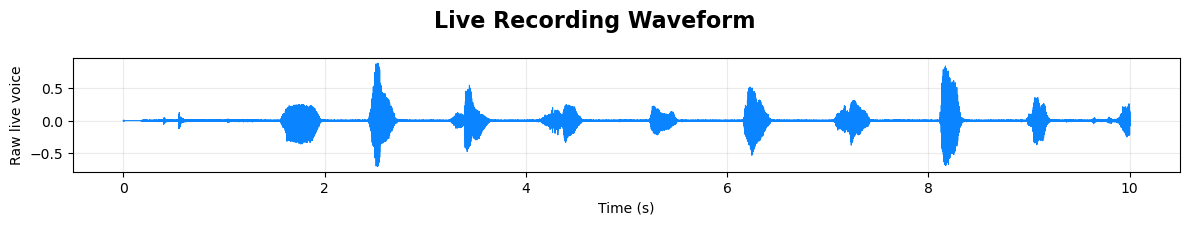

In [3]:
if USE_MIC:
    if sd is None:
        raise RuntimeError("sounddevice is not available. Set USE_MIC = False and rerun this cell.")
    print(f"Recording {RECORD_SECONDS} seconds. Please speak after the recording starts...")
    recording = sd.rec(int(RECORD_SECONDS * FS), samplerate=FS, channels=1, dtype="float32")
    sd.wait()
    raw_live = preprocess_audio(recording[:, 0], FS, seconds=RECORD_SECONDS)
else:
    print("Using backup audio instead of microphone recording:", BACKUP_AUDIO)
    backup, backup_fs = read_wav(BACKUP_AUDIO)
    backup = resample_if_needed(backup, backup_fs, FS)
    raw_live = preprocess_audio(backup, FS, seconds=RECORD_SECONDS)

save_wav(RAW_PATH, raw_live, FS)
print("Saved:", RAW_PATH)
show_audio("Raw live voice", raw_live, FS)
plot_waveforms({"Raw live voice": raw_live}, FS, "Live Recording Waveform", "live_raw_waveform.png")

## Cell 3｜Add High-Frequency Hiss Noise and Show Waveforms

Saved: /Users/xiejz959/Xiejz/College/Signal System & Probability/project/SSP_CP/demo/live_demo_outputs/live_hiss_noise.wav
Saved: /Users/xiejz959/Xiejz/College/Signal System & Probability/project/SSP_CP/demo/live_demo_outputs/live_noisy.wav
Raw live voice


Noisy live voice with simulated high-frequency hiss


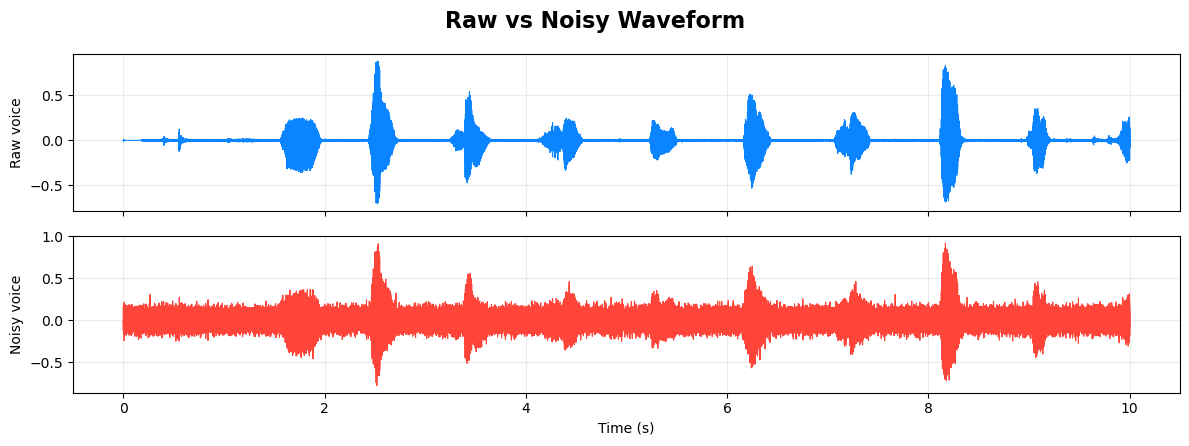

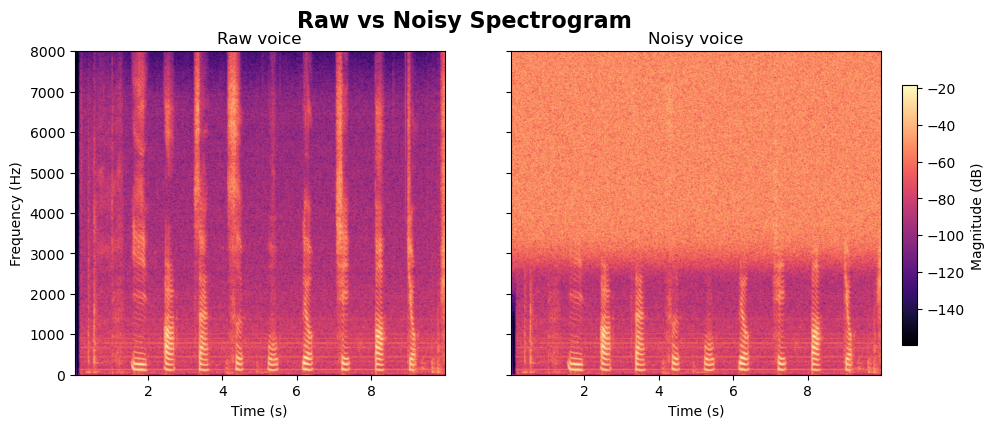

In [4]:
raw_live, fs = read_wav(RAW_PATH)
raw_live = resample_if_needed(raw_live, fs, FS)
raw_live = preprocess_audio(raw_live, FS, seconds=RECORD_SECONDS)

hiss_noise = make_hiss_noise(raw_live, FS, TARGET_SNR_DB, seed=RANDOM_SEED)
noisy_live = normalize_peak(raw_live + hiss_noise, 0.92)
raw_live, hiss_noise, noisy_live = match_length(raw_live, hiss_noise, noisy_live)

save_wav(NOISE_PATH, hiss_noise, FS)
save_wav(NOISY_PATH, noisy_live, FS)

print("Saved:", NOISE_PATH)
print("Saved:", NOISY_PATH)
show_audio("Raw live voice", raw_live, FS)
show_audio("Noisy live voice with simulated high-frequency hiss", noisy_live, FS)

plot_waveforms(
    {
        "Raw voice": raw_live,
        "Noisy voice": noisy_live,
    },
    FS,
    "Raw vs Noisy Waveform",
    "live_raw_vs_noisy_waveform.png",
)

plot_spectrograms(
    {
        "Raw voice": raw_live,
        "Noisy voice": noisy_live,
    },
    FS,
    "Raw vs Noisy Spectrogram",
    "live_raw_vs_noisy_spectrogram.png",
)

## Cell 4｜Baseline: Low-Pass Filtering

Baseline low-pass: cutoff = 3000 Hz, order = 6
Saved: /Users/xiejz959/Xiejz/College/Signal System & Probability/project/SSP_CP/demo/live_demo_outputs/live_lowpass.wav
Low-pass filtered voice


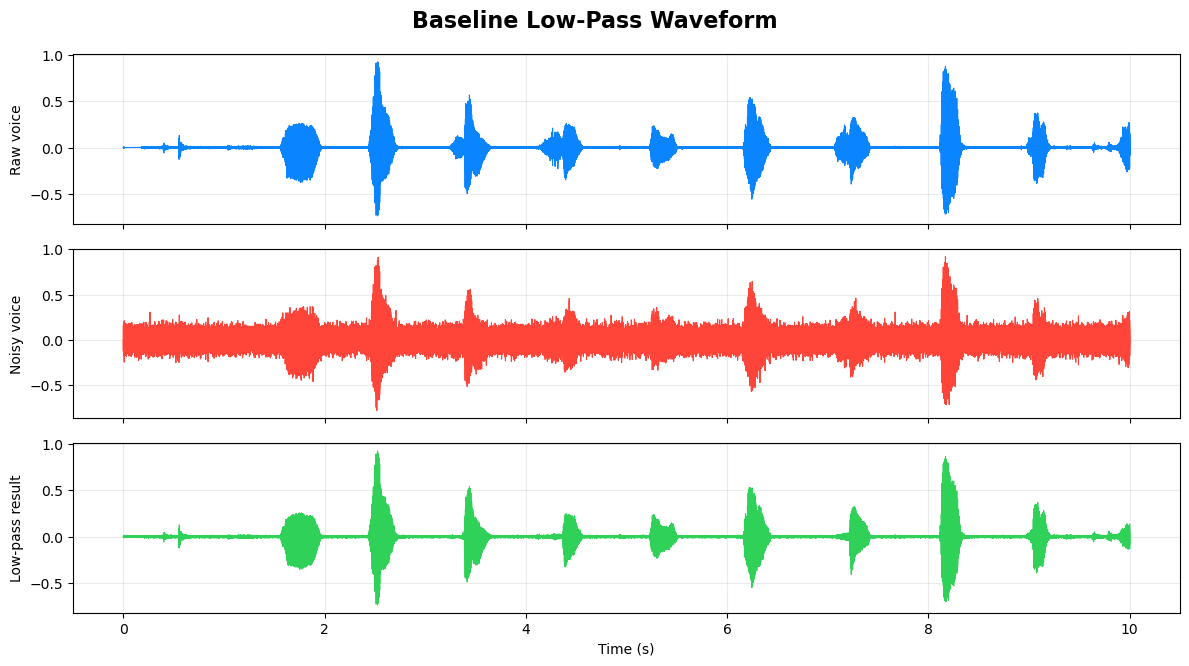

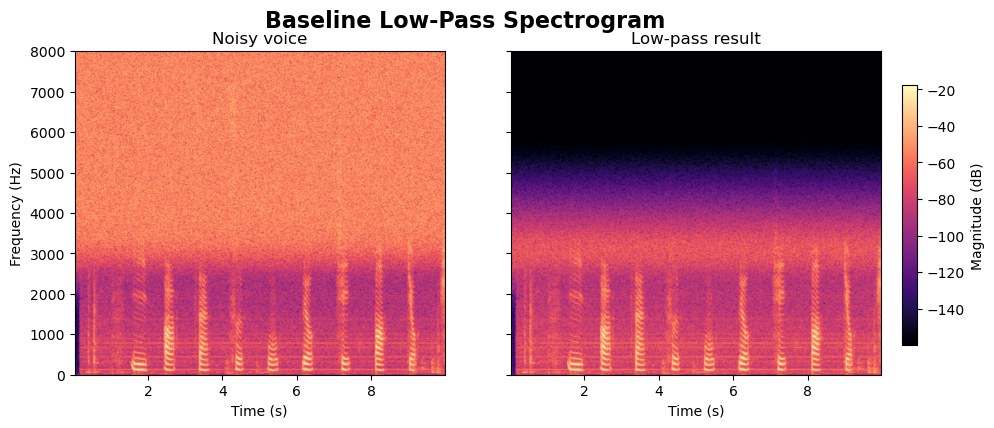

In [5]:
raw_live, _ = read_wav(RAW_PATH)
noisy_live, _ = read_wav(NOISY_PATH)
raw_live, noisy_live = match_length(raw_live, noisy_live)

lowpass_live = butter_lowpass(noisy_live, FS, LOWPASS_CUTOFF_HZ, LOWPASS_ORDER)
lowpass_live = lowpass_live[: len(noisy_live)]
save_wav(LOWPASS_PATH, lowpass_live, FS)

print(f"Baseline low-pass: cutoff = {LOWPASS_CUTOFF_HZ} Hz, order = {LOWPASS_ORDER}")
print("Saved:", LOWPASS_PATH)
show_audio("Low-pass filtered voice", lowpass_live, FS)

plot_waveforms(
    {
        "Raw voice": raw_live,
        "Noisy voice": noisy_live,
        "Low-pass result": lowpass_live,
    },
    FS,
    "Baseline Low-Pass Waveform",
    "live_lowpass_waveform.png",
)

plot_spectrograms(
    {
        "Noisy voice": noisy_live,
        "Low-pass result": lowpass_live,
    },
    FS,
    "Baseline Low-Pass Spectrogram",
    "live_lowpass_spectrogram.png",
)

## Cell 5｜Improved Method: Wiener-Style Time-Frequency Mask

Saved: /Users/xiejz959/Xiejz/College/Signal System & Probability/project/SSP_CP/demo/live_demo_outputs/live_mask.wav
Wiener-style mask filtered voice


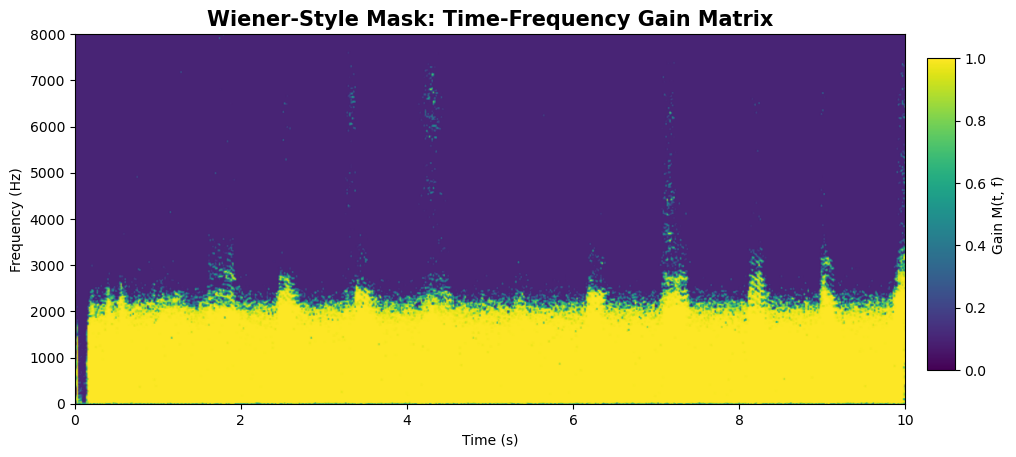

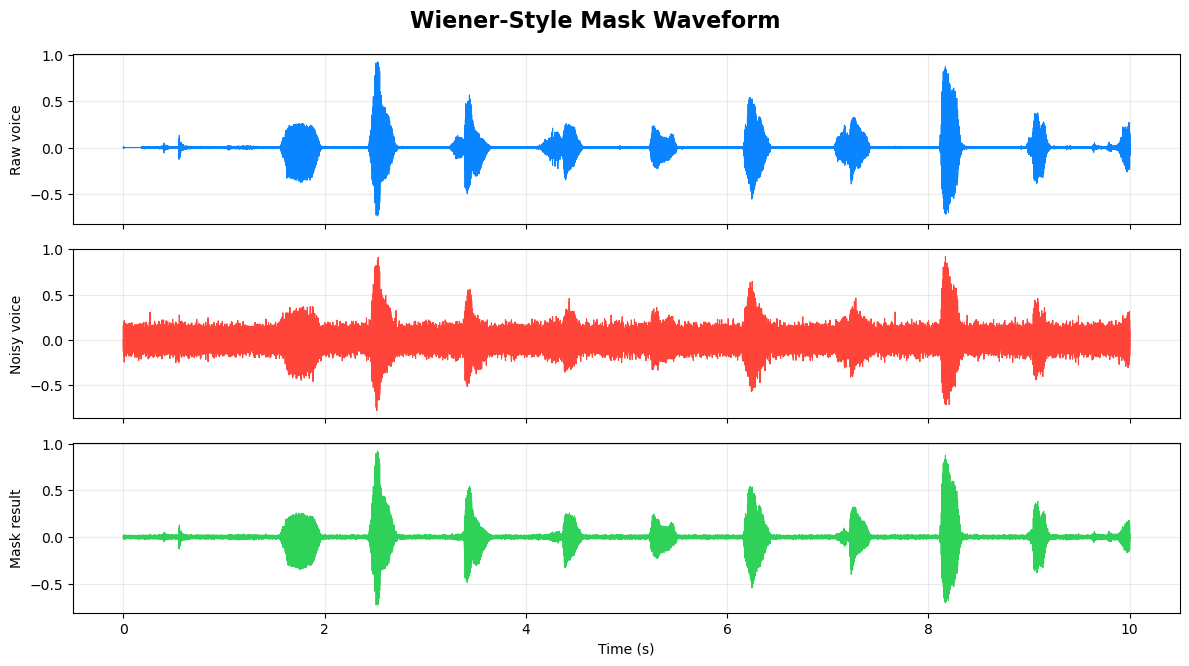

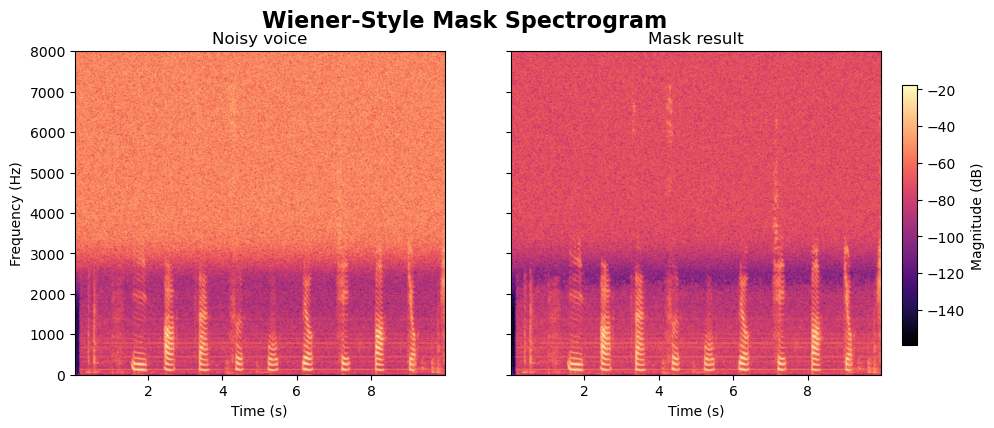

In [6]:
raw_live, _ = read_wav(RAW_PATH)
noisy_live, _ = read_wav(NOISY_PATH)
hiss_noise, _ = read_wav(NOISE_PATH)
raw_live, noisy_live, hiss_noise = match_length(raw_live, noisy_live, hiss_noise)

mask_live, mask_matrix, mask_freqs, mask_times = wiener_style_mask_filter(noisy_live, hiss_noise, FS)
mask_live = mask_live[: len(noisy_live)]
save_wav(MASK_PATH, mask_live, FS)

print("Saved:", MASK_PATH)
show_audio("Wiener-style mask filtered voice", mask_live, FS)

fig, ax = plt.subplots(figsize=(11, 4.8))
img = ax.pcolormesh(mask_times, mask_freqs, mask_matrix, shading="gouraud", cmap="viridis", vmin=0, vmax=1)
ax.set_title("Wiener-Style Mask: Time-Frequency Gain Matrix", fontsize=15, fontweight="bold")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_ylim(0, FS / 2)
fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.18, 0.025, 0.65])
fig.colorbar(img, cax=cax, label="Gain M(t, f)")
fig.savefig(OUTPUT_DIR / "live_wiener_mask_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

plot_waveforms(
    {
        "Raw voice": raw_live,
        "Noisy voice": noisy_live,
        "Mask result": mask_live,
    },
    FS,
    "Wiener-Style Mask Waveform",
    "live_mask_waveform.png",
)

plot_spectrograms(
    {
        "Noisy voice": noisy_live,
        "Mask result": mask_live,
    },
    FS,
    "Wiener-Style Mask Spectrogram",
    "live_mask_spectrogram.png",
)

## Cell 6｜Final Live Demo Comparison

Audio comparison
1. Raw live voice


2. Noisy live voice


3. Baseline low-pass result


4. Wiener-style mask result


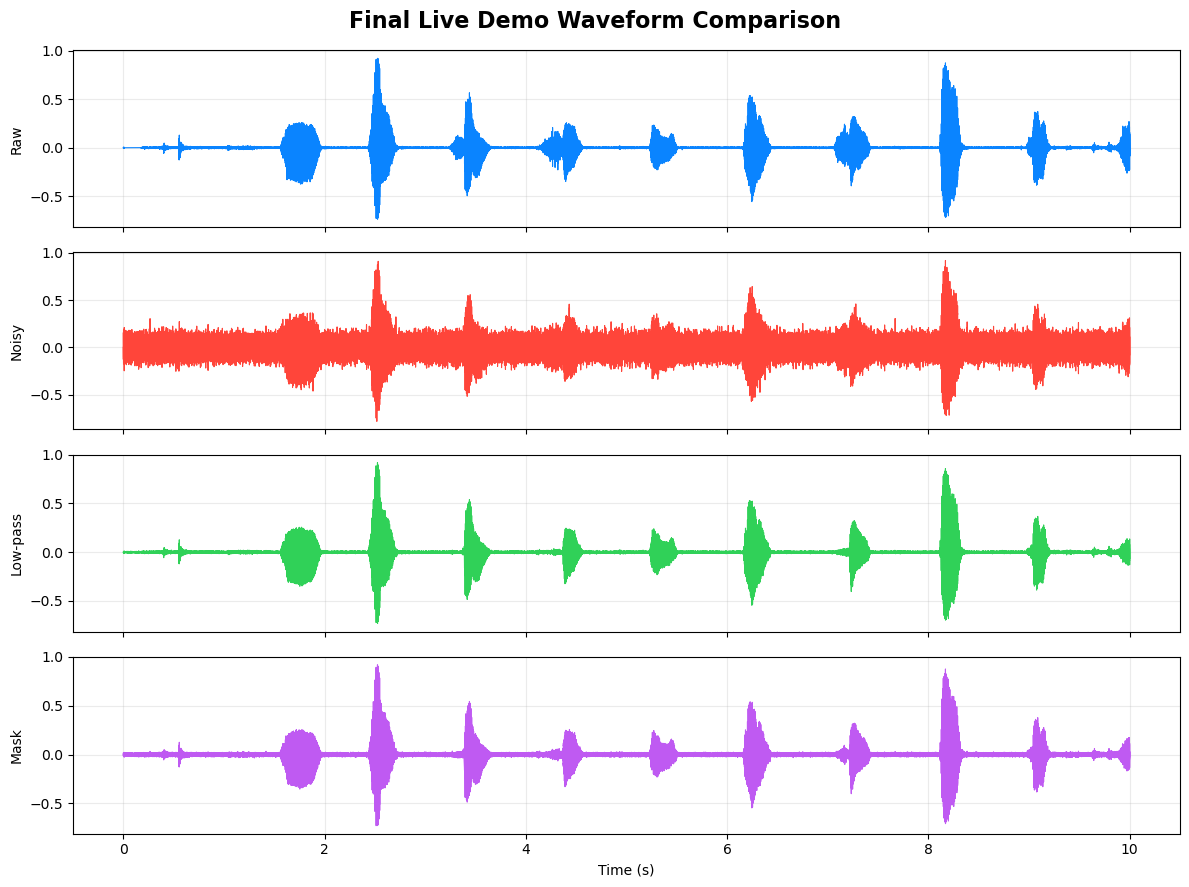

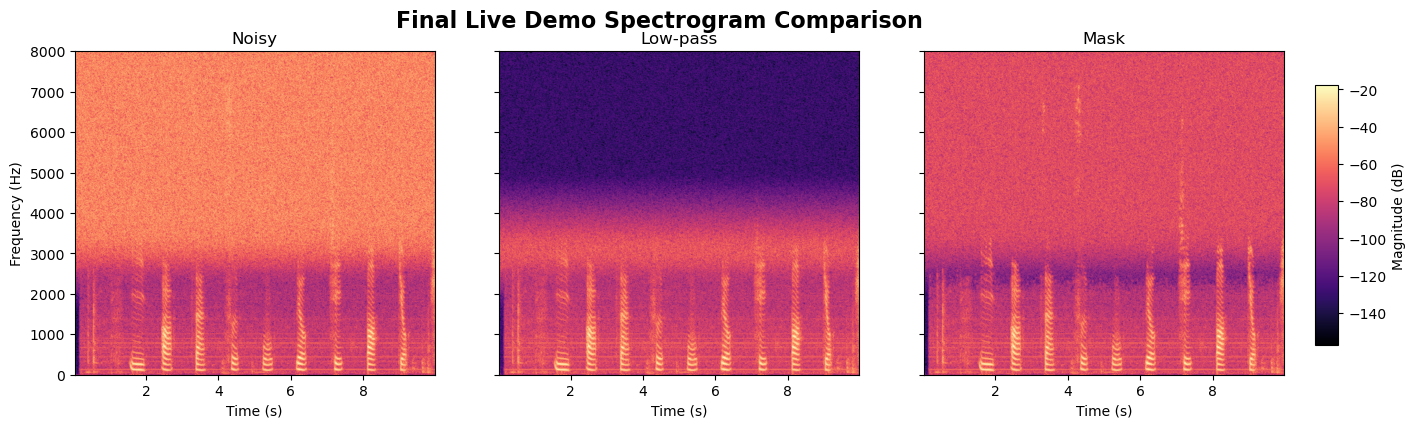

Live demo outputs saved in: /Users/xiejz959/Xiejz/College/Signal System & Probability/project/SSP_CP/demo/live_demo_outputs
- live_final_spectrogram_comparison.png
- live_final_waveform_comparison.png
- live_hiss_noise.wav
- live_lowpass.wav
- live_lowpass_spectrogram.png
- live_lowpass_waveform.png
- live_mask.wav
- live_mask_spectrogram.png
- live_mask_waveform.png
- live_noisy.wav
- live_raw.wav
- live_raw_vs_noisy_spectrogram.png
- live_raw_vs_noisy_waveform.png
- live_raw_waveform.png
- live_wiener_mask_matrix.png


In [7]:
raw_live, _ = read_wav(RAW_PATH)
noisy_live, _ = read_wav(NOISY_PATH)
lowpass_live, _ = read_wav(LOWPASS_PATH)
mask_live, _ = read_wav(MASK_PATH)
raw_live, noisy_live, lowpass_live, mask_live = match_length(raw_live, noisy_live, lowpass_live, mask_live)

print("Audio comparison")
show_audio("1. Raw live voice", raw_live, FS)
show_audio("2. Noisy live voice", noisy_live, FS)
show_audio("3. Baseline low-pass result", lowpass_live, FS)
show_audio("4. Wiener-style mask result", mask_live, FS)

plot_waveforms(
    {
        "Raw": raw_live,
        "Noisy": noisy_live,
        "Low-pass": lowpass_live,
        "Mask": mask_live,
    },
    FS,
    "Final Live Demo Waveform Comparison",
    "live_final_waveform_comparison.png",
)

plot_spectrograms(
    {
        "Noisy": noisy_live,
        "Low-pass": lowpass_live,
        "Mask": mask_live,
    },
    FS,
    "Final Live Demo Spectrogram Comparison",
    "live_final_spectrogram_comparison.png",
)

print("Live demo outputs saved in:", OUTPUT_DIR)
for path in sorted(OUTPUT_DIR.iterdir()):
    print("-", path.name)